# 📡 Telco Customer Churn Prediction — Complete Pipeline
### EDA · Feature Engineering · 6 Models · SMOTE · Hyperparameter Tuning · Hybrid Voting Ensemble · SHAP

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Goal:** Predict whether a customer will churn (leave the service)  
**Models:** Logistic Regression, Random Forest, XGBoost, LightGBM, KNN, Neural Network (MLP) + Soft Voting & Weighted Soft Voting Ensembles  
**Output:** Trained models + scaler + feature list saved as `.pkl` files for Streamlit app

---

## 1. Install & Import

In [1]:
!pip install shap imbalanced-learn lightgbm --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('=== Data Types & Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {(df["Churn"]=="Yes").mean():.1%}  ← imbalanced dataset!')

=== Data Types & Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

In [4]:
print('=== Basic Statistics ===')
df.describe()

=== Basic Statistics ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Exploratory Data Analysis

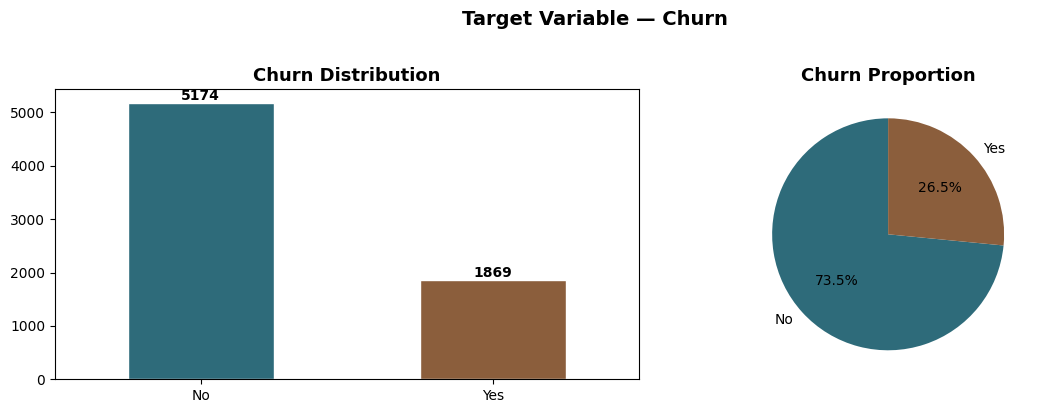

In [5]:
# Fix TotalCharges before EDA
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2e6b7a', '#8b5e3c'], edgecolor='white')
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

df['Churn'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2e6b7a', '#8b5e3c'], startangle=90)
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Target Variable — Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

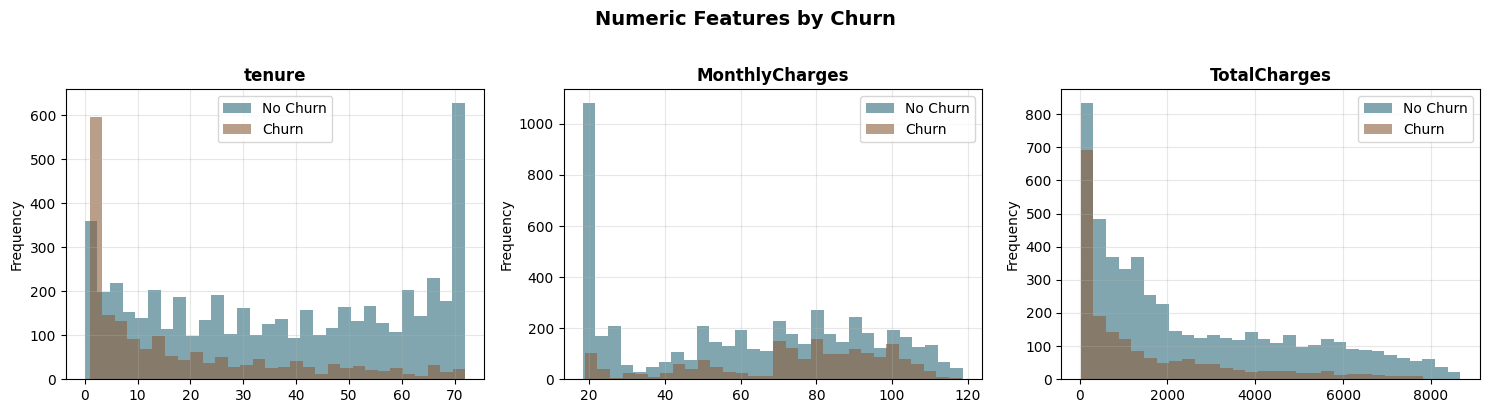

In [6]:
# Numeric features vs churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for ax, col in zip(axes, numeric_cols):
    df[df['Churn']=='No'][col].dropna().plot(
        kind='hist', ax=ax, alpha=0.6, color='#2e6b7a', label='No Churn', bins=30)
    df[df['Churn']=='Yes'][col].dropna().plot(
        kind='hist', ax=ax, alpha=0.6, color='#8b5e3c', label='Churn', bins=30)
    ax.set_title(col, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Numeric Features by Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

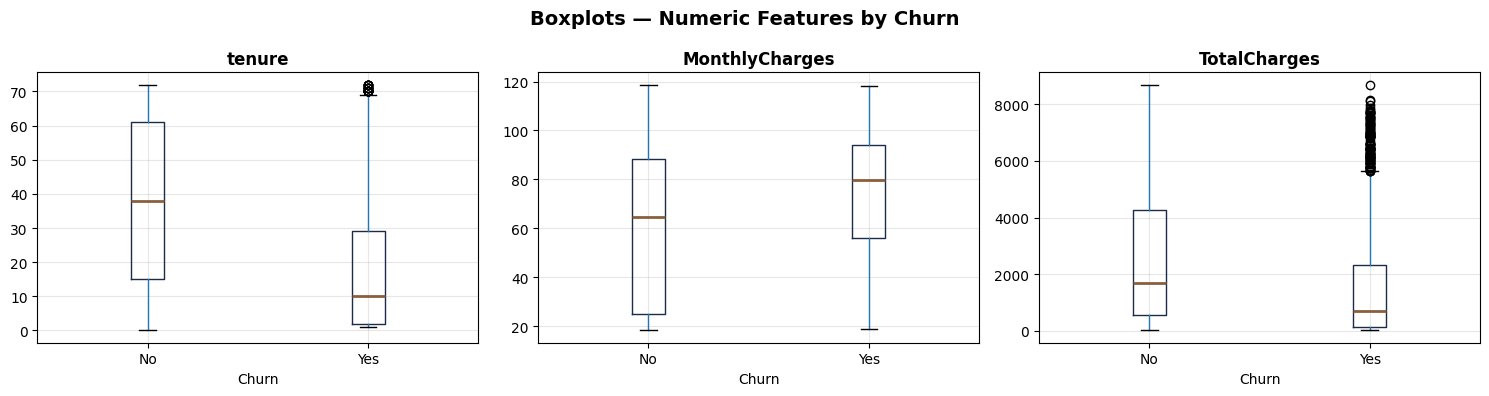

In [7]:
# Boxplots for numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='#1c2b4a'),
               medianprops=dict(color='#8b5e3c', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Churn')
    ax.grid(alpha=0.3)

plt.suptitle('Boxplots — Numeric Features by Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

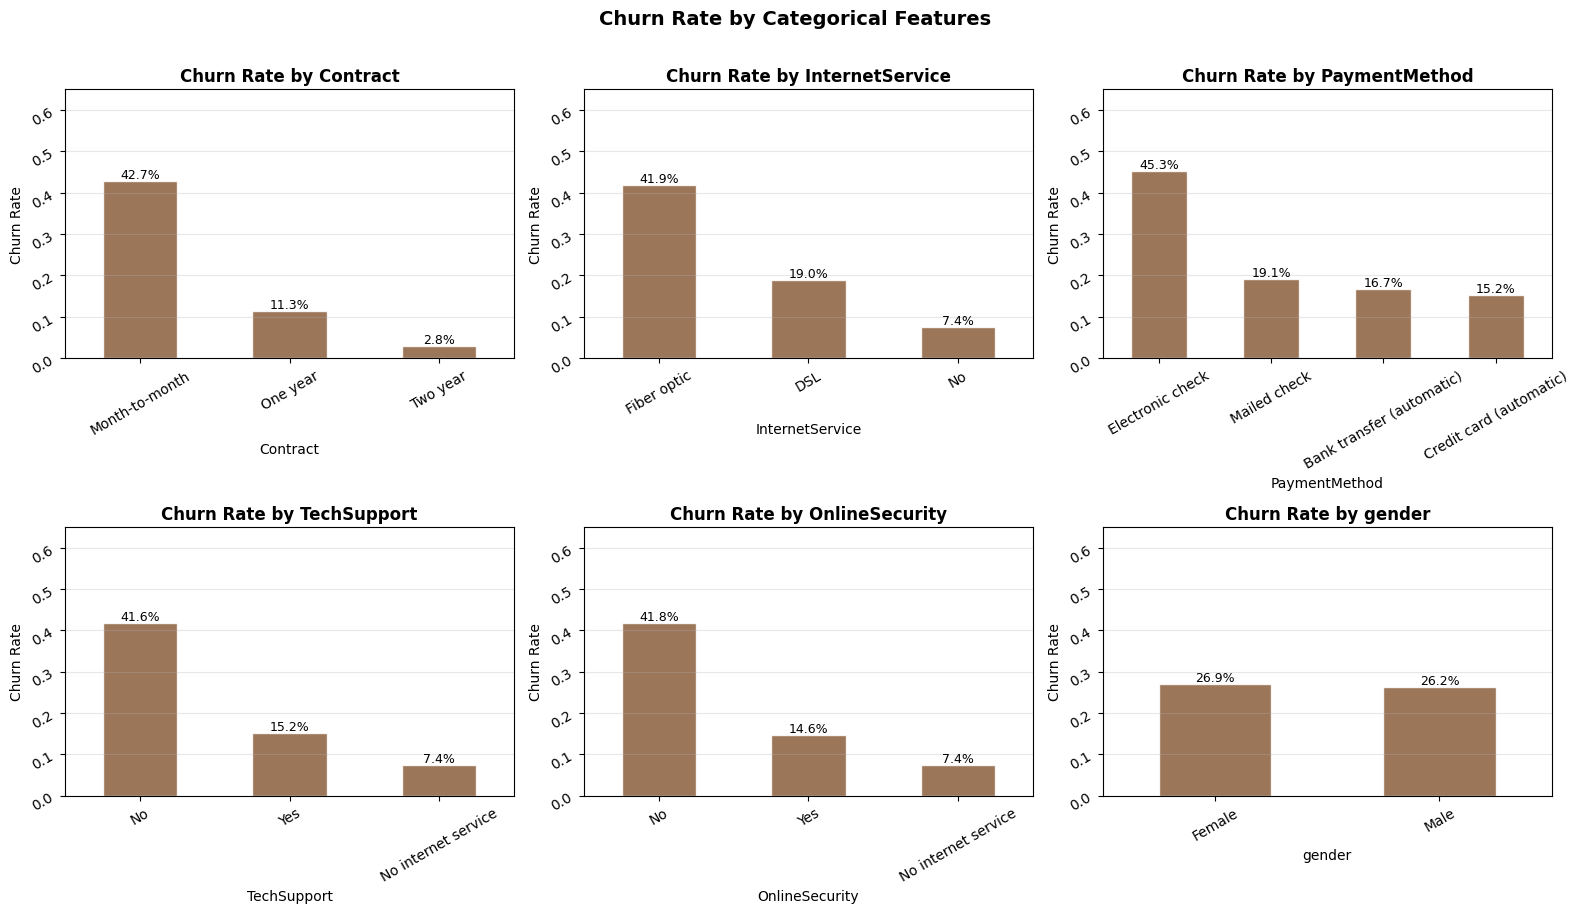

In [8]:
# Categorical features vs churn rate
cat_cols_eda = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_eda):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()).sort_values(ascending=False)
    bars = churn_rate.plot(kind='bar', ax=ax, color='#8b5e3c', edgecolor='white', alpha=0.85)
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(rotation=30)
    ax.set_ylim(0, 0.65)
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

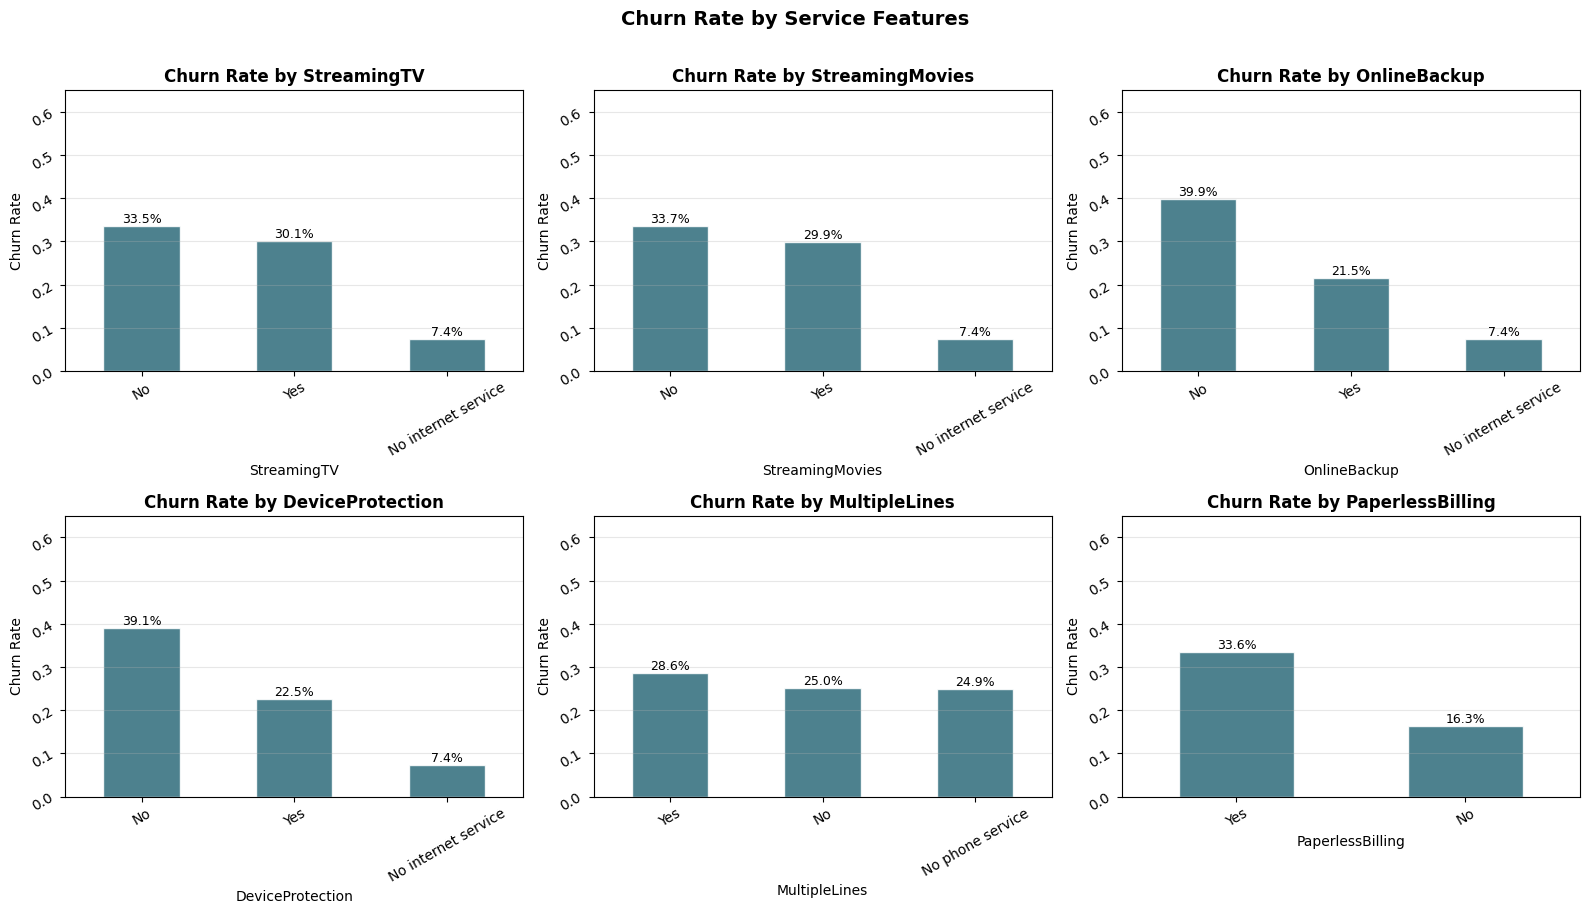

In [9]:
# More categorical features
cat_cols_eda2 = ['StreamingTV', 'StreamingMovies', 'OnlineBackup',
                 'DeviceProtection', 'MultipleLines', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_eda2):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()).sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#2e6b7a', edgecolor='white', alpha=0.85)
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.tick_params(rotation=30)
    ax.set_ylim(0, 0.65)
    ax.grid(axis='y', alpha=0.3)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Churn Rate by Service Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

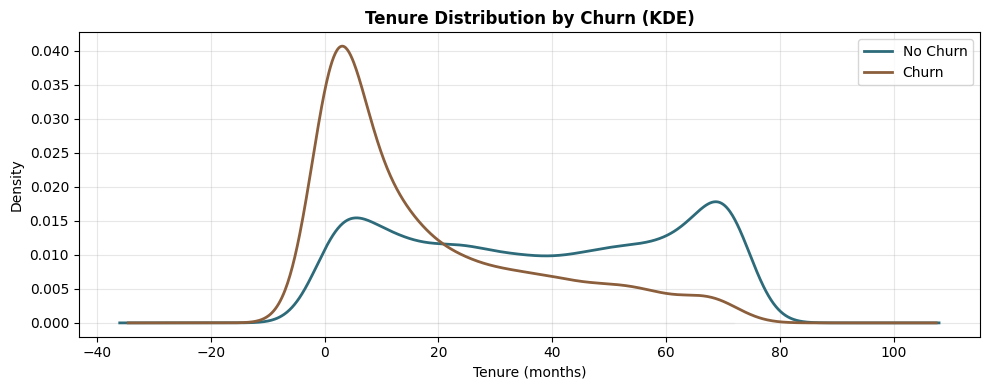

Key insight: New customers (low tenure) churn the most!


In [10]:
# Tenure vs churn — KDE plot
fig, ax = plt.subplots(figsize=(10, 4))
df[df['Churn']=='No']['tenure'].plot(kind='kde', ax=ax, color='#2e6b7a', label='No Churn', lw=2)
df[df['Churn']=='Yes']['tenure'].plot(kind='kde', ax=ax, color='#8b5e3c', label='Churn', lw=2)
ax.set_title('Tenure Distribution by Churn (KDE)', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.legend()
ax.grid(alpha=0.3)
ax.fill_between(np.linspace(0,72,200),
    [0]*200, alpha=0.05, color='#8b5e3c')
plt.tight_layout()
plt.show()
print('Key insight: New customers (low tenure) churn the most!')

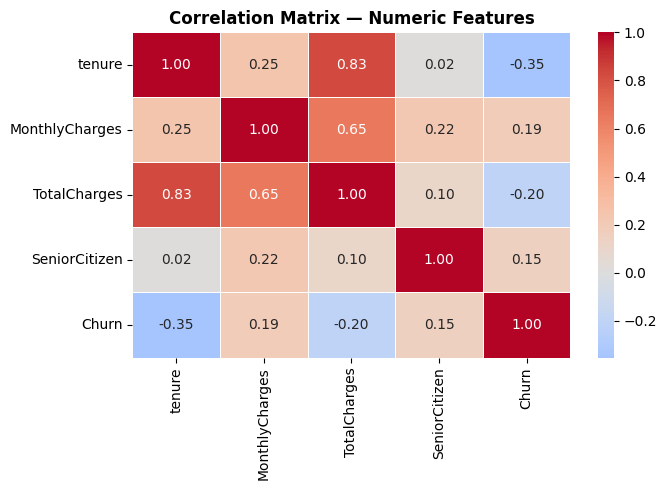

In [11]:
# Correlation heatmap (numeric columns)
df_num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
df_num['Churn'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

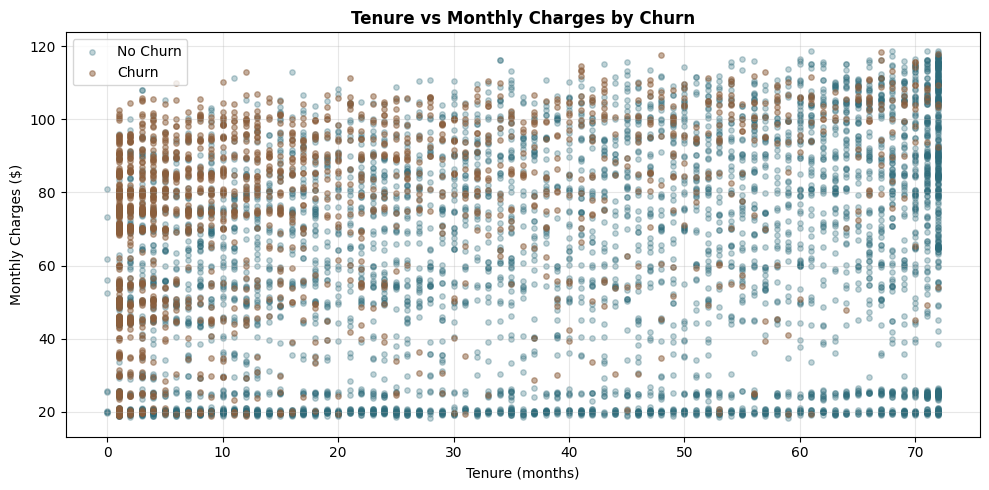

Key insight: High charges + low tenure = highest churn risk!


In [12]:
# Monthly charges vs tenure coloured by churn
fig, ax = plt.subplots(figsize=(10, 5))
no_churn = df[df['Churn']=='No']
churned  = df[df['Churn']=='Yes']
ax.scatter(no_churn['tenure'], no_churn['MonthlyCharges'],
           alpha=0.3, color='#2e6b7a', s=15, label='No Churn')
ax.scatter(churned['tenure'],  churned['MonthlyCharges'],
           alpha=0.5, color='#8b5e3c', s=15, label='Churn')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
ax.set_title('Tenure vs Monthly Charges by Churn', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Key insight: High charges + low tenure = highest churn risk!')

## 4. Preprocessing & Feature Engineering

In [13]:
df_clean = df.copy()

# --- Basic Cleaning ---
df_clean.drop('customerID', axis=1, inplace=True)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# --- Rich Feature Engineering ---
# Spend features
df_clean['AvgMonthlySpend']       = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)
df_clean['ChargePerMonth_ratio']  = df_clean['MonthlyCharges'] / (df_clean['TotalCharges'] + 1)
df_clean['SpendTrend']            = df_clean['MonthlyCharges'] - df_clean['AvgMonthlySpend']

# Tenure bucket
df_clean['TenureBucket'] = pd.cut(
    df_clean['tenure'], bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3], include_lowest=True).astype(int)

# Service count
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df_clean['NumServices'] = df_clean[service_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1)

# Business logic features
df_clean['HasInternet']          = (df_clean['InternetService'] != 'No').astype(int)
df_clean['IsMonthToMonth']       = (df_clean['Contract'] == 'Month-to-month').astype(int)
df_clean['IsLongTermContract']   = (df_clean['Contract'] == 'Two year').astype(int)
df_clean['HasNoSupport']         = (
    (df_clean['TechSupport'] == 'No') & (df_clean['OnlineSecurity'] == 'No')).astype(int)
df_clean['SeniorAlone']          = (
    (df_clean['SeniorCitizen'] == 1) & (df_clean['Partner'] == 'No')).astype(int)
df_clean['HighSpendNewCustomer'] = (
    (df_clean['MonthlyCharges'] > 70) & (df_clean['tenure'] < 12)).astype(int)
df_clean['LowEngagement']        = (
    (df_clean['NumServices'] <= 1) & (df_clean['IsMonthToMonth'] == 1)).astype(int)

print(f'Features after engineering: {df_clean.shape[1]}')
print('New features added:', ['AvgMonthlySpend','ChargePerMonth_ratio','SpendTrend',
      'TenureBucket','NumServices','HasInternet','IsMonthToMonth',
      'IsLongTermContract','HasNoSupport','SeniorAlone','HighSpendNewCustomer','LowEngagement'])

Features after engineering: 32
New features added: ['AvgMonthlySpend', 'ChargePerMonth_ratio', 'SpendTrend', 'TenureBucket', 'NumServices', 'HasInternet', 'IsMonthToMonth', 'IsLongTermContract', 'HasNoSupport', 'SeniorAlone', 'HighSpendNewCustomer', 'LowEngagement']


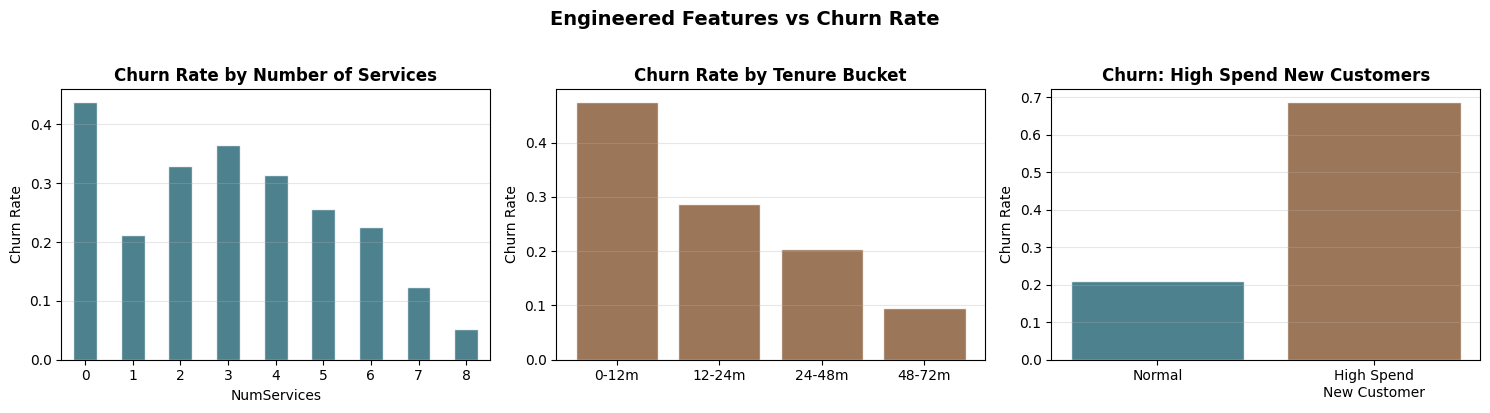

In [14]:
# Visualise engineered features vs churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# NumServices vs churn rate
svc_churn = df_clean.groupby('NumServices')['Churn'].mean()
svc_churn.plot(kind='bar', ax=axes[0], color='#2e6b7a', edgecolor='white', alpha=0.85)
axes[0].set_title('Churn Rate by Number of Services', fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# TenureBucket vs churn rate
tenure_labels = ['0-12m', '12-24m', '24-48m', '48-72m']
tb_churn = df_clean.groupby('TenureBucket')['Churn'].mean()
axes[1].bar(tenure_labels[:len(tb_churn)], tb_churn.values,
            color='#8b5e3c', edgecolor='white', alpha=0.85)
axes[1].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].grid(axis='y', alpha=0.3)

# HighSpendNewCustomer vs churn rate
hsnc = df_clean.groupby('HighSpendNewCustomer')['Churn'].mean()
axes[2].bar(['Normal', 'High Spend\nNew Customer'], hsnc.values,
            color=['#2e6b7a','#8b5e3c'], edgecolor='white', alpha=0.85)
axes[2].set_title('Churn: High Spend New Customers', fontweight='bold')
axes[2].set_ylabel('Churn Rate')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Engineered Features vs Churn Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# --- Encode ---
binary_cols = [c for c in df_clean.select_dtypes('object').columns
               if set(df_clean[c].unique()) <= {'Yes', 'No', 'No phone service', 'No internet service'}]
for col in binary_cols:
    df_clean[col] = df_clean[col].map(lambda x: 1 if x == 'Yes' else 0)

df_clean['gender'] = LabelEncoder().fit_transform(df_clean['gender'])

remaining_cats = df_clean.select_dtypes('object').columns.tolist()
print(f'One-hot encoding: {remaining_cats}')
df_clean = pd.get_dummies(df_clean, columns=remaining_cats, drop_first=True)

print(f'\nFinal shape: {df_clean.shape}')
print(f'Total features: {df_clean.shape[1] - 1}')

One-hot encoding: ['InternetService', 'Contract', 'PaymentMethod']

Final shape: (7043, 36)
Total features: 35


## 5. Train/Test Split + SMOTE

In [16]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}')

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_names)

# SMOTE on training set only — never on test!
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
print(f'\nBefore SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_bal).value_counts())}')

Train: (5634, 35) | Test: (1409, 35)
Train churn rate: 26.54% | Test churn rate: 26.54%

Before SMOTE: {0: np.int64(4139), 1: np.int64(1495)}
After  SMOTE: {0: np.int64(4139), 1: np.int64(4139)}


## 6. Baseline Model Comparison (No Tuning)

In [17]:
# Quick baseline before tuning — so we can see improvement
baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(eval_metric='logloss', verbosity=0, random_state=42),
    'LightGBM':            LGBMClassifier(random_state=42, verbose=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
}

print('=== Baseline Results (default hyperparameters) ===')
print(f'{"Model":25s} | Accuracy | ROC-AUC | F1-Churn')
print('-' * 60)
baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    baseline_results[name] = {'accuracy': acc, 'roc_auc': auc, 'f1': f1}
    print(f'{name:25s} | {acc:.4f}   | {auc:.4f}  | {f1:.4f}')

=== Baseline Results (default hyperparameters) ===
Model                     | Accuracy | ROC-AUC | F1-Churn
------------------------------------------------------------
Logistic Regression       | 0.7374   | 0.8459  | 0.6146
Random Forest             | 0.7715   | 0.8257  | 0.5796
XGBoost                   | 0.7715   | 0.8178  | 0.5649
LightGBM                  | 0.7807   | 0.8304  | 0.5929
KNN                       | 0.6891   | 0.7660  | 0.5447
Neural Network            | 0.7516   | 0.7825  | 0.5358


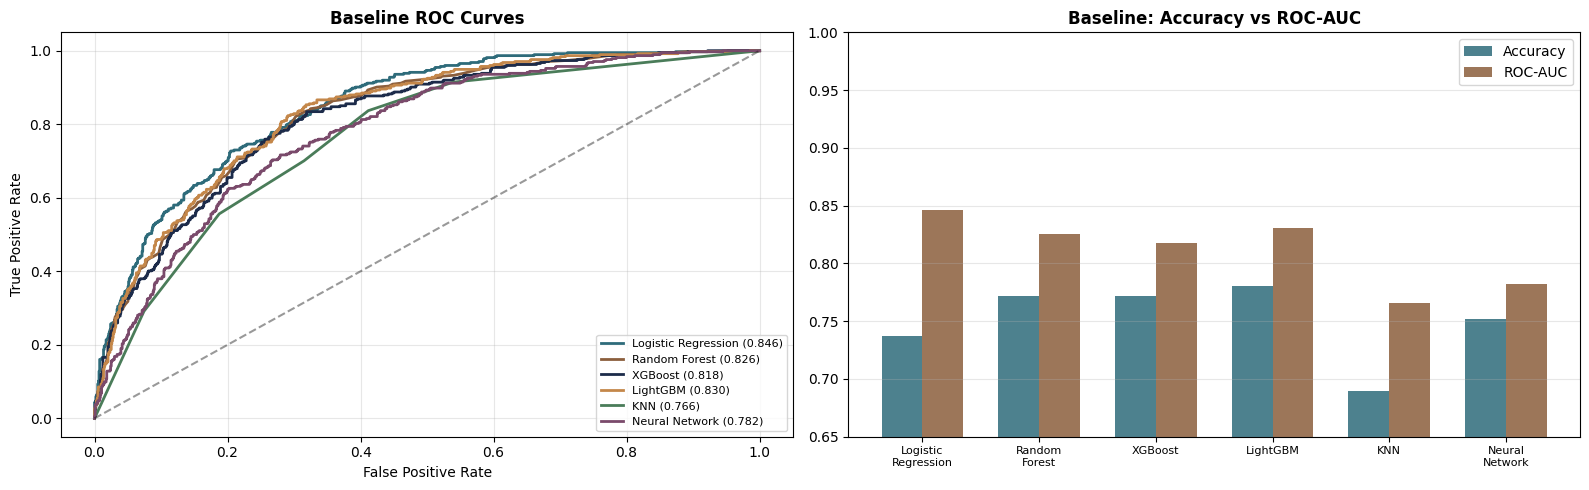

In [18]:
# Visualise baseline results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#2e6b7a','#8b5e3c','#1c2b4a','#c4874a','#4a7c59','#7a4a6b']
names_b = list(baseline_results.keys())

# ROC curves
for (name, model), color in zip(baseline_models.items(), colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = baseline_results[name]['roc_auc']
    axes[0].plot(fpr, tpr, label=f'{name} ({auc:.3f})', color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('Baseline ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(alpha=0.3)

# Bar chart
x = np.arange(len(names_b))
w = 0.35
accs_b = [baseline_results[n]['accuracy'] for n in names_b]
aucs_b = [baseline_results[n]['roc_auc']  for n in names_b]
axes[1].bar(x - w/2, accs_b, w, label='Accuracy', color='#2e6b7a', alpha=0.85)
axes[1].bar(x + w/2, aucs_b, w, label='ROC-AUC',  color='#8b5e3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ',  '\n') for n in names_b], fontsize=8)
axes[1].set_ylim(0.65, 1.0)
axes[1].set_title('Baseline: Accuracy vs ROC-AUC', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — All 6 Models

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── XGBoost ────────────────────────────────────────────────────────────
print('🔧 Tuning XGBoost...')
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', verbosity=0, random_state=42),
    {
        'n_estimators':     [100, 200, 300, 500],
        'max_depth':        [3, 4, 5, 6],
        'learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'subsample':        [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha':        [0, 0.1, 0.5],
        'reg_lambda':       [1, 1.5, 2],
    },
    n_iter=40, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
xgb_search.fit(X_train_bal, y_train_bal)
best_xgb = xgb_search.best_estimator_
print(f'   Best CV AUC: {xgb_search.best_score_:.4f}')
print(f'   Best params: {xgb_search.best_params_}')

🔧 Tuning XGBoost...
   Best CV AUC: 0.9395
   Best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [20]:
# ── LightGBM ───────────────────────────────────────────────────────────
print('🔧 Tuning LightGBM...')
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [-1, 5, 10, 15],
        'learning_rate':     [0.01, 0.05, 0.1, 0.2],
        'num_leaves':        [20, 31, 50, 70],
        'subsample':         [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
        'reg_alpha':         [0, 0.1, 0.5],
        'reg_lambda':        [0, 0.1, 1.0],
        'min_child_samples': [10, 20, 30],
    },
    n_iter=40, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
lgbm_search.fit(X_train_bal, y_train_bal)
best_lgbm = lgbm_search.best_estimator_
print(f'   Best CV AUC: {lgbm_search.best_score_:.4f}')
print(f'   Best params: {lgbm_search.best_params_}')

🔧 Tuning LightGBM...
   Best CV AUC: 0.9398
   Best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 70, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [21]:
# ── Random Forest ──────────────────────────────────────────────────────
print('🔧 Tuning Random Forest...')
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2', 0.5],
        'class_weight':      ['balanced', None],
    },
    n_iter=30, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
rf_search.fit(X_train_bal, y_train_bal)
best_rf = rf_search.best_estimator_
print(f'   Best CV AUC: {rf_search.best_score_:.4f}')
print(f'   Best params: {rf_search.best_params_}')

🔧 Tuning Random Forest...
   Best CV AUC: 0.9290
   Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced'}


In [22]:
# ── Logistic Regression ────────────────────────────────────────────────
print('🔧 Tuning Logistic Regression...')
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    {
        'C':            [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty':      ['l1', 'l2', 'elasticnet'],
        'solver':       ['saga'],
        'l1_ratio':     [0.1, 0.3, 0.5, 0.7, 0.9],
        'class_weight': ['balanced', None],
    },
    n_iter=30, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
lr_search.fit(X_train_bal, y_train_bal)
best_lr = lr_search.best_estimator_
print(f'   Best CV AUC: {lr_search.best_score_:.4f}')
print(f'   Best params: {lr_search.best_params_}')

🔧 Tuning Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_

   Best CV AUC: 0.8552
   Best params: {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.3, 'class_weight': 'balanced', 'C': 100}


In [23]:
# ── KNN ────────────────────────────────────────────────────────────────
print('🔧 Tuning KNN...')
knn_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan', 'minkowski'],
        'p':           [1, 2],
    },
    n_iter=30, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
knn_search.fit(X_train_bal, y_train_bal)
best_knn = knn_search.best_estimator_
print(f'   Best CV AUC: {knn_search.best_score_:.4f}')
print(f'   Best params: {knn_search.best_params_}')

🔧 Tuning KNN...
   Best CV AUC: 0.9070
   Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 7, 'metric': 'minkowski'}


In [24]:
# ── Neural Network (MLP) ───────────────────────────────────────────────
print('🔧 Tuning Neural Network (MLP)...')
mlp_search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    {
        'hidden_layer_sizes': [(64,), (128,), (64,32), (128,64), (128,64,32), (256,128,64)],
        'activation':         ['relu', 'tanh'],
        'alpha':              [0.0001, 0.001, 0.01, 0.1],
        'learning_rate':      ['constant', 'adaptive'],
        'learning_rate_init': [0.001, 0.01, 0.0001],
        'batch_size':         [32, 64, 128],
    },
    n_iter=30, cv=cv, scoring='roc_auc', random_state=42, n_jobs=-1
)
mlp_search.fit(X_train_bal, y_train_bal)
best_mlp = mlp_search.best_estimator_
print(f'   Best CV AUC: {mlp_search.best_score_:.4f}')
print(f'   Best params: {mlp_search.best_params_}')

🔧 Tuning Neural Network (MLP)...
   Best CV AUC: 0.9063
   Best params: {'learning_rate_init': 0.001, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (256, 128, 64), 'batch_size': 64, 'alpha': 0.1, 'activation': 'relu'}


## 8. Hybrid Voting Ensembles (XGBoost + LightGBM + Random Forest)

In [25]:
# ── Soft Voting (equal weights) ────────────────────────────────────────
print('🔧 Training Soft Voting Ensemble...')
soft_voting = VotingClassifier(
    estimators=[
        ('xgb',  best_xgb),
        ('lgbm', best_lgbm),
        ('rf',   best_rf),
    ],
    voting='soft',
    n_jobs=-1
)
soft_voting.fit(X_train_bal, y_train_bal)
print('✅ Soft Voting trained')

# ── Weighted Soft Voting (weights proportional to CV AUC) ─────────────
print('🔧 Training Weighted Soft Voting Ensemble...')
xgb_auc  = xgb_search.best_score_
lgbm_auc = lgbm_search.best_score_
rf_auc   = rf_search.best_score_

# Normalise weights so they sum to 1, then scale to integers for readability
total = xgb_auc + lgbm_auc + rf_auc
w_xgb  = round(xgb_auc  / total * 10, 2)
w_lgbm = round(lgbm_auc / total * 10, 2)
w_rf   = round(rf_auc   / total * 10, 2)
print(f'   Weights → XGBoost: {w_xgb:.2f} | LightGBM: {w_lgbm:.2f} | Random Forest: {w_rf:.2f}')

weighted_voting = VotingClassifier(
    estimators=[
        ('xgb',  best_xgb),
        ('lgbm', best_lgbm),
        ('rf',   best_rf),
    ],
    voting='soft',
    weights=[w_xgb, w_lgbm, w_rf],
    n_jobs=-1
)
weighted_voting.fit(X_train_bal, y_train_bal)
print('✅ Weighted Soft Voting trained')

🔧 Training Soft Voting Ensemble...
✅ Soft Voting trained
🔧 Training Weighted Soft Voting Ensemble...
   Weights → XGBoost: 3.35 | LightGBM: 3.35 | Random Forest: 3.31
✅ Weighted Soft Voting trained


## 9. Evaluate All Tuned Models

In [26]:
candidates = {
    'XGBoost':             best_xgb,
    'LightGBM':            best_lgbm,
    'Random Forest':       best_rf,
    'Logistic Regression': best_lr,
    'KNN':                 best_knn,
    'Neural Network':      best_mlp,
    'Soft Voting':         soft_voting,
    'Weighted Soft Voting':weighted_voting,
}

results = {}
print(f'=== Tuned Model Results ===')
print(f'{"Model":25s} | Accuracy | ROC-AUC | F1-Churn')
print('-' * 60)

for name, model in candidates.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)
    results[name] = {'model': model, 'accuracy': acc, 'roc_auc': auc,
                     'f1': f1, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'{name:25s} | {acc:.4f}   | {auc:.4f}  | {f1:.4f}')

=== Tuned Model Results ===
Model                     | Accuracy | ROC-AUC | F1-Churn
------------------------------------------------------------
XGBoost                   | 0.7857   | 0.8374  | 0.5941
LightGBM                  | 0.7800   | 0.8354  | 0.5964
Random Forest             | 0.7743   | 0.8307  | 0.5891
Logistic Regression       | 0.7360   | 0.8453  | 0.6117
KNN                       | 0.7331   | 0.7753  | 0.5534
Neural Network            | 0.7665   | 0.8060  | 0.5766
Soft Voting               | 0.7793   | 0.8384  | 0.5881
Weighted Soft Voting      | 0.7793   | 0.8383  | 0.5881


In [27]:
# Before vs after tuning comparison (individual models only)
print('\n=== Improvement from Tuning ===' )
print(f'{"Model":25s} | Baseline AUC | Tuned AUC | Gain')
print('-' * 60)
for name in baseline_results:
    base  = baseline_results[name]['roc_auc']
    tuned = results[name]['roc_auc']
    gain  = tuned - base
    print(f'{name:25s} | {base:.4f}       | {tuned:.4f}    | +{gain:.4f}')
print()
print('Soft Voting AUC         :', round(results['Soft Voting']['roc_auc'], 4))
print('Weighted Soft Voting AUC:', round(results['Weighted Soft Voting']['roc_auc'], 4))


=== Improvement from Tuning ===
Model                     | Baseline AUC | Tuned AUC | Gain
------------------------------------------------------------
Logistic Regression       | 0.8459       | 0.8453    | +-0.0005
Random Forest             | 0.8257       | 0.8307    | +0.0051
XGBoost                   | 0.8178       | 0.8374    | +0.0195
LightGBM                  | 0.8304       | 0.8354    | +0.0050
KNN                       | 0.7660       | 0.7753    | +0.0093
Neural Network            | 0.7825       | 0.8060    | +0.0235

Soft Voting AUC         : 0.8384
Weighted Soft Voting AUC: 0.8383


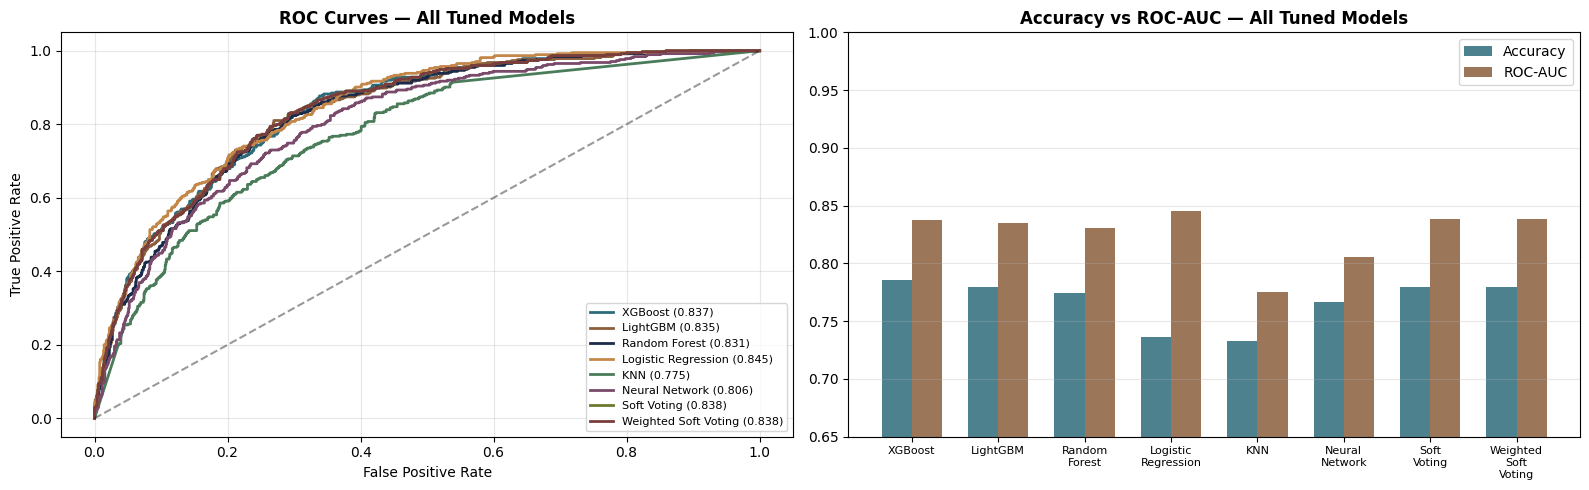

In [28]:
# Full visual comparison
colors = ['#2e6b7a','#8b5e3c','#1c2b4a','#c4874a','#4a7c59','#7a4a6b','#6b7a2e','#7a3c3c']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} ({res['roc_auc']:.3f})", color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curves — All Tuned Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(alpha=0.3)

names  = list(results.keys())
accs   = [results[n]['accuracy'] for n in names]
aucs   = [results[n]['roc_auc']  for n in names]
x = np.arange(len(names))
w = 0.35
axes[1].bar(x - w/2, accs, w, label='Accuracy', color='#2e6b7a', alpha=0.85)
axes[1].bar(x + w/2, aucs, w, label='ROC-AUC',  color='#8b5e3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ','\n') for n in names], fontsize=8)
axes[1].set_ylim(0.65, 1.0)
axes[1].set_title('Accuracy vs ROC-AUC — All Tuned Models', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Threshold Optimisation on Best Model

🏆 Best model: Logistic Regression


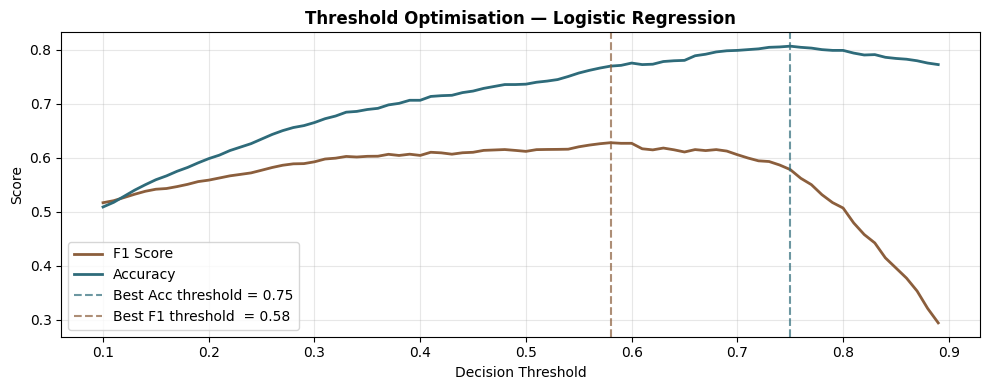


Default (0.5)      → Accuracy: 0.7360
Optimised (0.75)   → Accuracy: 0.8062


In [29]:
best_name = max(results, key=lambda n: results[n]['roc_auc'])
best = results[best_name]
best_model = best['model']
print(f'🏆 Best model: {best_name}')

thresholds  = np.arange(0.1, 0.9, 0.01)
f1_scores   = [f1_score(y_test, (best['y_proba'] >= t).astype(int)) for t in thresholds]
acc_scores  = [accuracy_score(y_test, (best['y_proba'] >= t).astype(int)) for t in thresholds]

best_thresh_acc = thresholds[np.argmax(acc_scores)]
best_thresh_f1  = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores,  label='F1 Score', color='#8b5e3c', lw=2)
plt.plot(thresholds, acc_scores, label='Accuracy', color='#2e6b7a', lw=2)
plt.axvline(best_thresh_acc, color='#2e6b7a', linestyle='--', alpha=0.7,
            label=f'Best Acc threshold = {best_thresh_acc:.2f}')
plt.axvline(best_thresh_f1,  color='#8b5e3c', linestyle='--', alpha=0.7,
            label=f'Best F1 threshold  = {best_thresh_f1:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title(f'Threshold Optimisation — {best_name}', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nDefault (0.5)      → Accuracy: {accuracy_score(y_test,(best["y_proba"]>=0.5).astype(int)):.4f}')
print(f'Optimised ({best_thresh_acc:.2f})   → Accuracy: {max(acc_scores):.4f}')

=== Final Results: Logistic Regression @ threshold=0.75 ===
Accuracy : 0.8062
ROC-AUC  : 0.8453
F1 Score : 0.5781

              precision    recall  f1-score   support

    No Churn       0.84      0.92      0.87      1035
       Churn       0.68      0.50      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



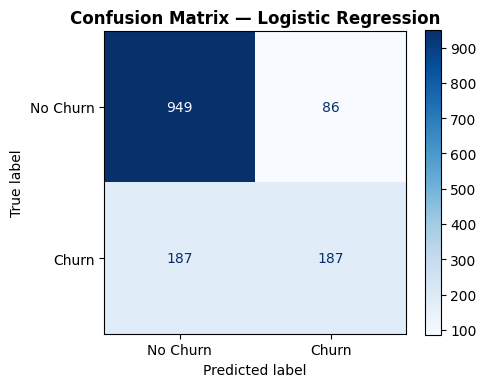

In [30]:
BEST_THRESHOLD = float(best_thresh_acc)
y_pred_final   = (best['y_proba'] >= BEST_THRESHOLD).astype(int)

print(f'=== Final Results: {best_name} @ threshold={BEST_THRESHOLD:.2f} ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC  : {best["roc_auc"]:.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. SHAP Explainability

In [31]:
print('Computing SHAP values...')

# Use best tree-based model for SHAP
# (Voting/MLP/KNN don't support TreeExplainer natively)
if best_name in ['XGBoost', 'LightGBM', 'Random Forest']:
    shap_model = best_model
    shap_label = best_name
else:
    # Fall back to LightGBM as SHAP proxy
    shap_model = best_lgbm
    shap_label = f'LightGBM (SHAP proxy — winner was {best_name})'

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_scaled)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f'✅ SHAP computed using: {shap_label}')

Computing SHAP values...
✅ SHAP computed using: LightGBM (SHAP proxy — winner was Logistic Regression)


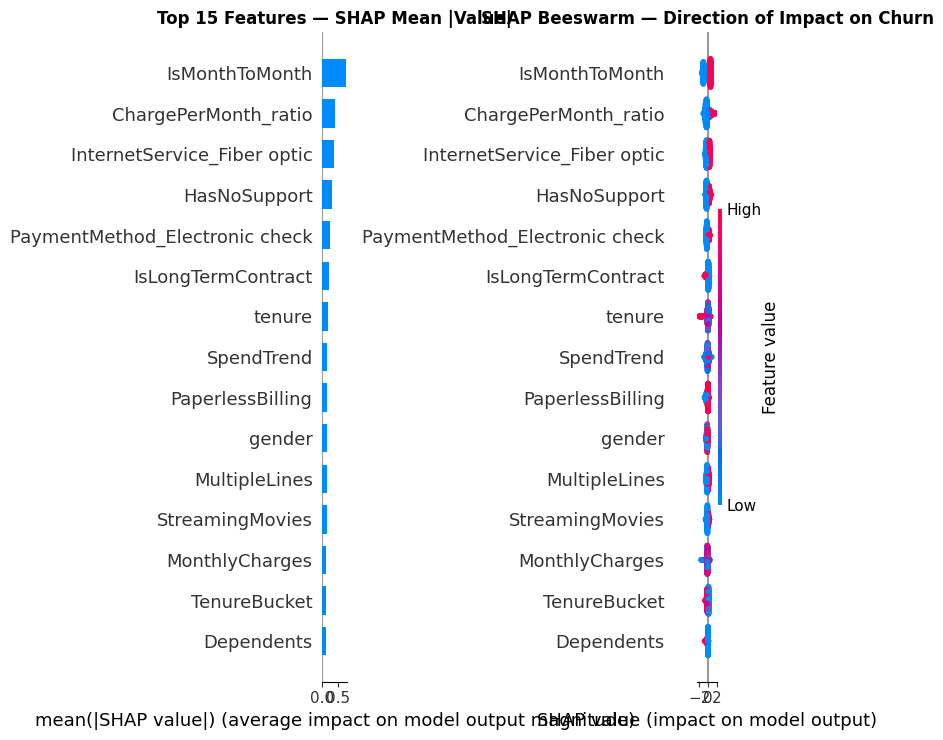

In [32]:
# Global feature importance
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False, max_display=15)
axes[0].set_title('Top 15 Features — SHAP Mean |Value|', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_scaled, show=False, max_display=15)
axes[1].set_title('SHAP Beeswarm — Direction of Impact on Churn', fontweight='bold')

plt.tight_layout()
plt.show()

SHAP explanation for a single churned customer (test index 9):


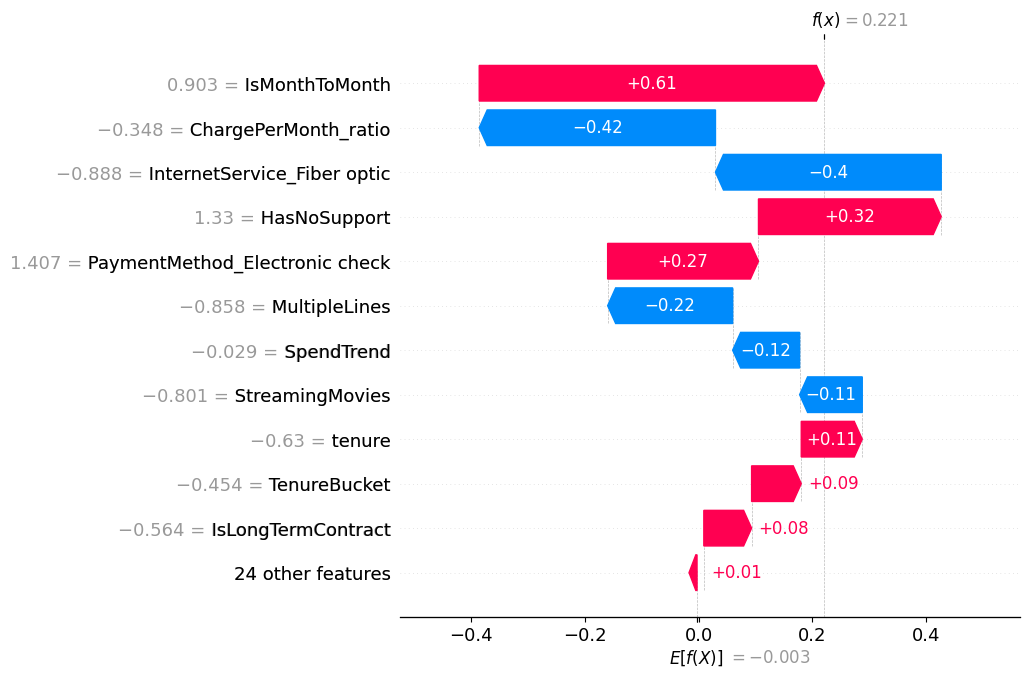

In [33]:
# SHAP waterfall for a single churned customer
churn_indices = np.where(y_test.values == 1)[0]
sample_idx = churn_indices[0]

print(f'SHAP explanation for a single churned customer (test index {sample_idx}):')
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_test_scaled.iloc[sample_idx],
        feature_names=feature_names
    ),
    max_display=12
)

## 12. Export All Model Files

In [34]:
import os
os.makedirs('/kaggle/working/churn_model', exist_ok=True)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_auc      = best['roc_auc']
final_f1       = f1_score(y_test, y_pred_final)

# All individual tuned models
all_models = {
    'XGBoost':             best_xgb,
    'LightGBM':            best_lgbm,
    'Random Forest':       best_rf,
    'Logistic Regression': best_lr,
    'KNN':                 best_knn,
    'Neural Network':      best_mlp,
    'Soft Voting':         soft_voting,
    'Weighted Soft Voting':weighted_voting,
}
with open('/kaggle/working/churn_model/all_models.pkl', 'wb') as f:
    pickle.dump(all_models, f)

# Best model
with open('/kaggle/working/churn_model/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Scaler
with open('/kaggle/working/churn_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Feature names
with open('/kaggle/working/churn_model/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Threshold
with open('/kaggle/working/churn_model/threshold.pkl', 'wb') as f:
    pickle.dump(BEST_THRESHOLD, f)

# Metadata + all results summary
results_summary = {
    name: {
        'accuracy': round(res['accuracy'], 4),
        'roc_auc':  round(res['roc_auc'],  4),
        'f1':       round(res['f1'],        4),
    }
    for name, res in results.items()
}
metadata = {
    'model_name':  best_name,
    'accuracy':    round(final_accuracy, 4),
    'roc_auc':     round(final_auc, 4),
    'f1_score':    round(final_f1, 4),
    'threshold':   round(BEST_THRESHOLD, 2),
    'n_features':  len(feature_names),
    'train_size':  len(X_train),
    'test_size':   len(X_test),
    'smote_used':  True,
    'all_results': results_summary,
}
with open('/kaggle/working/churn_model/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print('✅ All files exported:')
for fname in sorted(os.listdir('/kaggle/working/churn_model/')):
    size = os.path.getsize(f'/kaggle/working/churn_model/{fname}')
    print(f'  {fname:30s} {size/1024:.1f} KB')

print(f'\n🏆 Winner       : {best_name}')
print(f'   Accuracy     : {final_accuracy:.4f}')
print(f'   ROC-AUC      : {final_auc:.4f}')
print(f'   F1 Score     : {final_f1:.4f}')
print(f'   Threshold    : {BEST_THRESHOLD:.2f}')
print(f'\n📊 All model results:')
for name, res in results_summary.items():
    print(f'   {name:25s} Acc={res["accuracy"]}  AUC={res["roc_auc"]}  F1={res["f1"]}')

✅ All files exported:
  all_models.pkl                 98102.5 KB
  feature_names.pkl              0.6 KB
  metadata.pkl                   0.8 KB
  model.pkl                      1.7 KB
  scaler.pkl                     2.0 KB
  threshold.pkl                  0.0 KB

🏆 Winner       : Logistic Regression
   Accuracy     : 0.8062
   ROC-AUC      : 0.8453
   F1 Score     : 0.5781
   Threshold    : 0.75

📊 All model results:
   XGBoost                   Acc=0.7857  AUC=0.8374  F1=0.5941
   LightGBM                  Acc=0.78  AUC=0.8354  F1=0.5964
   Random Forest             Acc=0.7743  AUC=0.8307  F1=0.5891
   Logistic Regression       Acc=0.736  AUC=0.8453  F1=0.6117
   KNN                       Acc=0.7331  AUC=0.7753  F1=0.5534
   Neural Network            Acc=0.7665  AUC=0.806  F1=0.5766
   Soft Voting               Acc=0.7793  AUC=0.8384  F1=0.5881
   Weighted Soft Voting      Acc=0.7793  AUC=0.8383  F1=0.5881


## ✅ Done!

Download these **6 files** from the **Output tab → `/kaggle/working/churn_model/`**:

| File | Contents |
|------|----------|
| `model.pkl` | Best single model |
| `all_models.pkl` | All 7 trained models |
| `scaler.pkl` | Fitted StandardScaler |
| `feature_names.pkl` | Feature name list |
| `metadata.pkl` | All scores + model name + results summary |
| `threshold.pkl` | Optimised decision threshold |

Place all 6 in a `model/` folder in your Streamlit project.